# 22A PatchCore EfficientNet-B1 One-Layer All-in-One x240

This notebook runs the local EfficientNet-B1 PatchCore x240 follow-up using the repo's report-compatible anomaly protocol.

What it does in one run:

- reads raw `LSWMD.pkl`
- rebuilds the shared `40k / 5k / 5k + 250` split used throughout `REPORT.md`
- fits a one-layer `EfficientNet-B1` PatchCore model on train-normal wafers only
- applies the same deployment threshold rule used across the repo:
  - threshold = `95th` percentile of validation-normal raw scores
- reevaluates the same fitted checkpoint on the secondary `70k` normal / `3.5k` defect holdout
- exports post-hoc UMAP diagnostics from the main benchmark checkpoint
- saves CSV, JSON, plot, and checkpoint artifacts under `experiments/anomaly_detection/patchcore/efficientnet_b1/x240/main_one_layer/artifacts/patchcore_efficientnet_b1_one_layer`


## Submission Context

- Dataset notebook: `data/dataset/x240/benchmark_50k_5pct/notebook.ipynb`
- Dataset config: `data/dataset/x240/benchmark_50k_5pct/data_config.toml`
- Experiment config: `embedded in notebook`
- Artifact root: `experiments/anomaly_detection/patchcore/efficientnet_b1/x240/main_one_layer/artifacts/`
- Notes:
  - This notebook rebuilds the x240 benchmark internally and also reevaluates on the x64 secondary holdout after fitting the main model.

In [19]:
from __future__ import annotations

import copy
import os
import json
import pickle
import random
import sys
import time
from pathlib import Path
from typing import Any

import numpy as np
import pandas as pd
import pandas.core.indexes as core_indexes
import torch
import torch.nn as nn
import torch.nn.functional as F
from sklearn.decomposition import PCA
from sklearn.metrics import average_precision_score, precision_recall_curve, roc_auc_score
from sklearn.neighbors import NearestNeighbors
from torch.utils.data import DataLoader, Dataset
from tqdm.auto import tqdm
from torchvision.models import EfficientNet_B1_Weights, efficientnet_b1

torch.backends.cudnn.benchmark = True
torch.backends.cuda.matmul.allow_tf32 = True
torch.backends.cudnn.allow_tf32 = True
torch.set_float32_matmul_precision("high")


LABEL_NORMAL = "none"
LABEL_DEFECT = "pattern"


def find_project_root() -> Path:
    for candidate in [Path.cwd(), *Path.cwd().parents]:
        if (candidate / ".git").exists() or ((candidate / "artifacts").exists() and (candidate / "notebooks").exists()):
            return candidate.resolve()
    return Path.cwd().resolve()


PROJECT_ROOT = find_project_root()

SRC_ROOT = PROJECT_ROOT / "src"
if str(SRC_ROOT) not in sys.path:
    sys.path.insert(0, str(SRC_ROOT))

from wafer_defect.evaluation import export_reference_umap_bundle


def resolve_project_path(path_str: str | Path) -> Path:
    path = Path(path_str)
    if path.is_absolute():
        return path.resolve()
    return (PROJECT_ROOT / path).resolve()


def auto_find_raw_pickle(path_str: str | Path) -> Path:
    candidate = Path(path_str)
    candidates = []
    if candidate.is_absolute():
        candidates.append(candidate)
    else:
        candidates.extend([
            candidate,
            resolve_project_path(candidate),
            PROJECT_ROOT / "data" / "raw" / candidate.name,
        ])

    for item in candidates:
        if item.exists():
            return item.resolve()

    recursive_hits = list((PROJECT_ROOT / "data").rglob(candidate.name)) if (PROJECT_ROOT / "data").exists() else []
    if recursive_hits:
        return recursive_hits[0].resolve()

    raise FileNotFoundError(f"Raw pickle not found. Tried: {[str(x) for x in candidates]}")


CONFIG: dict[str, Any] = {

    "run": {
        "variant_name": "effnet_b1_one_layer_patchcore_x240",
        "raw_pickle": "data/raw/LSWMD.pkl",
        "output_dir": "experiments/anomaly_detection/patchcore/efficientnet_b1/x240/main_one_layer/artifacts/patchcore_efficientnet_b1_one_layer",
        "seed": 42,
        "rebuild_dataset": False,
    },
    "split": {
        "image_size": 240,
        "train_normal_count": 40_000,
        "val_normal_count": 5_000,
        "test_normal_count": 5_000,
        "test_defect_fraction_of_test_normals": 0.05,
    },
    "model": {
        "device": "auto",
        "model_input_size": 240,
        "batch_size": 96,
        "num_workers": 0,
        "persistent_workers": False,
        "prefetch_factor": 2,
        "memory_bank_max_patches": 240_000,
        "score_chunk": 1024,
        "patchcore_nn_k": 3,
        "topk_patch_ratio": 0.03,
        "effnet_feature_idx": 3,
        "patch_embed_dim": 512,
        "amp": True,
    },
    "scoring": {
        "threshold_quantile": 0.95,
    },
}


def set_seed(seed: int) -> None:
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    if torch.cuda.is_available():
        torch.cuda.manual_seed_all(seed)



def resolve_device(device_name: str) -> torch.device:
    if device_name == "auto":
        return torch.device("cuda" if torch.cuda.is_available() else "cpu")
    return torch.device(device_name)


def resolve_loader_workers(requested_workers: int) -> int:
    # Windows notebook kernels often fail to pickle these large in-memory array datasets.
    if os.name == "nt":
        return 0
    return max(0, int(requested_workers))


def read_legacy_pickle(path: str | Path) -> pd.DataFrame:
    sys.modules["pandas.indexes"] = core_indexes
    with Path(path).open("rb") as handle:
        return pickle.load(handle, encoding="latin1")


def unwrap_legacy_value(value: Any) -> str:
    if value is None:
        return ""
    if hasattr(value, "size") and getattr(value, "size") == 0:
        return ""
    if hasattr(value, "tolist"):
        value = value.tolist()
    while isinstance(value, list) and len(value) == 1:
        value = value[0]
    return str(value).strip()


def normalize_map(wafer_map: np.ndarray, image_size: int) -> np.ndarray:
    wafer_map = np.asarray(wafer_map, dtype=np.float32) / 2.0
    tensor = torch.from_numpy(wafer_map).unsqueeze(0).unsqueeze(0)
    return F.interpolate(tensor, size=(image_size, image_size), mode="nearest").squeeze(0).squeeze(0).numpy()


def infer_label_from_row(row: pd.Series) -> str | None:
    failure = unwrap_legacy_value(row.get("failureType", "")).lower()
    if failure == "none":
        return LABEL_NORMAL
    if failure:
        return LABEL_DEFECT
    return None


def build_split_from_raw(config: dict[str, Any]) -> dict[str, np.ndarray]:
    raw_path = auto_find_raw_pickle(config["run"]["raw_pickle"])

    image_size = int(config["split"]["image_size"])
    train_n = int(config["split"]["train_normal_count"])
    val_n = int(config["split"]["val_normal_count"])
    test_n = int(config["split"]["test_normal_count"])
    defect_fraction = float(config["split"]["test_defect_fraction_of_test_normals"])
    requested_defects = max(1, int(round(test_n * defect_fraction)))
    seed = int(config["run"]["seed"])

    df = read_legacy_pickle(raw_path).copy()
    df["failureTypeText"] = df["failureType"].map(unwrap_legacy_value)
    df["label"] = df.apply(infer_label_from_row, axis=1)
    df = df[df["label"].notna()].reset_index(drop=True)

    normal_df = df[df["label"] == LABEL_NORMAL].sample(frac=1.0, random_state=seed).reset_index(drop=True)
    defect_df = df[df["label"] == LABEL_DEFECT].sample(frac=1.0, random_state=seed).reset_index(drop=True)

    required_normals = train_n + val_n + test_n
    if len(normal_df) < required_normals:
        raise ValueError(f"Need {required_normals} normals but found {len(normal_df)}")
    if len(defect_df) < requested_defects:
        raise ValueError(f"Need {requested_defects} defects but found {len(defect_df)}")

    train_df = normal_df.iloc[:train_n].copy()
    val_df = normal_df.iloc[train_n : train_n + val_n].copy()
    test_normal_df = normal_df.iloc[train_n + val_n : train_n + val_n + test_n].copy()
    test_defect_df = defect_df.iloc[:requested_defects].copy()
    test_df = pd.concat([test_normal_df, test_defect_df], ignore_index=True).sample(frac=1.0, random_state=seed).reset_index(drop=True)

    print(
        "Prepared split | "
        f"train normals={len(train_df)} | "
        f"val normals={len(val_df)} | "
        f"test normals={len(test_normal_df)} | "
        f"test defects={len(test_defect_df)}"
    )

    def to_arrays(frame: pd.DataFrame, split_name: str) -> tuple[np.ndarray, np.ndarray, np.ndarray]:
        arrays = np.stack(
            [
                normalize_map(np.asarray(row["waferMap"]), image_size=image_size)
                for _, row in tqdm(frame.iterrows(), total=len(frame), desc=f"prepare_{split_name}", leave=True)
            ]
        )
        labels = (frame["label"].values == LABEL_DEFECT).astype(np.int64)
        defect_types = frame["failureTypeText"].fillna("unlabeled").replace("", "unlabeled").to_numpy()
        return arrays, labels, defect_types

    train_x, train_y, train_defect_types = to_arrays(train_df, "train")
    val_x, val_y, val_defect_types = to_arrays(val_df, "val")
    test_x, test_y, test_defect_types = to_arrays(test_df, "test")

    return {
        "train_x": train_x,
        "train_y": train_y,
        "train_defect_types": train_defect_types,
        "val_x": val_x,
        "val_y": val_y,
        "val_defect_types": val_defect_types,
        "test_x": test_x,
        "test_y": test_y,
        "test_defect_types": test_defect_types,
    }


class EfficientNetArrayDataset(Dataset):
    def __init__(self, arrays: np.ndarray, labels: np.ndarray, model_input_size: int) -> None:
        self.arrays = arrays.astype(np.float32)
        self.labels = labels.astype(np.int64)
        self.model_input_size = int(model_input_size)

    def __len__(self) -> int:
        return len(self.labels)

    def __getitem__(self, index: int) -> tuple[torch.Tensor, torch.Tensor]:
        x = torch.from_numpy(self.arrays[index])
        states = torch.clamp(torch.round(x * 2.0), 0, 2).to(dtype=torch.long)
        one_hot = F.one_hot(states, num_classes=3).permute(2, 0, 1).to(dtype=torch.float32)
        if one_hot.shape[-1] != self.model_input_size or one_hot.shape[-2] != self.model_input_size:
            one_hot = F.interpolate(
                one_hot.unsqueeze(0),
                size=(self.model_input_size, self.model_input_size),
                mode="nearest",
            ).squeeze(0)
        y = torch.tensor(int(self.labels[index]), dtype=torch.long)
        return one_hot, y



class EfficientNetB1OneLayerPatchCoreModel(nn.Module):
    def __init__(
        self,
        *,
        model_input_size: int,
        feature_idx: int,
        patch_embed_dim: int,
        topk_ratio: float,
        nn_k: int,
        query_chunk_size: int,
        amp_enabled: bool,
    ) -> None:
        super().__init__()
        backbone = efficientnet_b1(weights=EfficientNet_B1_Weights.DEFAULT)
        self.features = backbone.features
        self.feature_idx = int(feature_idx)
        self.patch_embed_dim = int(patch_embed_dim)
        self.topk_ratio = float(topk_ratio)
        self.nn_k = int(nn_k)
        self.query_chunk_size = int(query_chunk_size)
        self.amp_enabled = bool(amp_enabled)

        with torch.inference_mode():
            dummy = torch.zeros(1, 3, model_input_size, model_input_size)
            x = dummy
            selected = None
            for i, block in enumerate(self.features):
                x = block(x)
                if i == self.feature_idx:
                    selected = x
                    break

        if selected is None:
            raise ValueError(f"Invalid EfficientNet-B1 feature index: {self.feature_idx}")

        in_dim = int(selected.shape[1])
        self.patch_grid = tuple(int(dim) for dim in selected.shape[-2:])
        self.feature_dim = self.patch_embed_dim
        self.proj = nn.Linear(in_dim, self.patch_embed_dim, bias=False)
        self.register_buffer("memory_bank", torch.empty(0, self.feature_dim))

        for parameter in self.features.parameters():
            parameter.requires_grad_(False)
        for parameter in self.proj.parameters():
            parameter.requires_grad_(False)

    @property
    def patches_per_image(self) -> int:
        return int(self.patch_grid[0] * self.patch_grid[1])

    def forward_feature_map(self, x: torch.Tensor) -> torch.Tensor:
        selected = None
        for i, block in enumerate(self.features):
            x = block(x)
            if i == self.feature_idx:
                selected = x
                break
        if selected is None:
            raise RuntimeError("Failed to collect EfficientNet-B1 feature map.")
        return selected

    def patch_embeddings(self, x: torch.Tensor) -> torch.Tensor:
        amp_enabled = self.amp_enabled and x.device.type == "cuda"
        with torch.inference_mode():
            with torch.autocast(device_type=x.device.type, dtype=torch.float16, enabled=amp_enabled):
                feat = self.forward_feature_map(x)
                emb = feat.permute(0, 2, 3, 1).reshape(-1, feat.shape[1])
                emb = self.proj(emb)
            emb = F.normalize(emb.float(), p=2, dim=1)
        return emb.reshape(x.shape[0], self.patches_per_image, self.feature_dim)

    def image_embeddings(self, x: torch.Tensor) -> torch.Tensor:
        return self.patch_embeddings(x).mean(dim=1)

    def set_memory_bank(self, memory_bank: torch.Tensor) -> None:
        if memory_bank.ndim != 2 or memory_bank.shape[1] != self.feature_dim:
            raise ValueError(
                f"memory_bank must have shape (N, {self.feature_dim}), got {tuple(memory_bank.shape)}"
            )
        normalized = F.normalize(memory_bank.to(dtype=torch.float32), p=2, dim=1)
        self.memory_bank = normalized.to(device=self.memory_bank.device, dtype=self.memory_bank.dtype)

    def nearest_patch_distances(self, patch_embeddings: torch.Tensor) -> torch.Tensor:
        if self.memory_bank.numel() == 0:
            raise ValueError("memory_bank is empty.")

        batch_size, patch_count, _ = patch_embeddings.shape
        flat_queries = patch_embeddings.reshape(-1, self.feature_dim)
        bank_t = self.memory_bank.t().contiguous()
        outputs = []

        for start in range(0, flat_queries.shape[0], self.query_chunk_size):
            query_chunk = flat_queries[start : start + self.query_chunk_size]
            sim = query_chunk @ bank_t
            k = min(self.nn_k, sim.shape[1])
            best_sim = sim.topk(k=k, dim=1).values
            dist = torch.sqrt(torch.clamp(2.0 - 2.0 * best_sim, min=0.0))
            outputs.append(dist.mean(dim=1))

        return torch.cat(outputs, dim=0).reshape(batch_size, patch_count)

    def reduce_patch_distances(self, patch_distances: torch.Tensor) -> torch.Tensor:
        topk = max(1, int(round(patch_distances.shape[1] * self.topk_ratio)))
        topk = min(topk, patch_distances.shape[1])
        return torch.topk(patch_distances, k=topk, dim=1).values.mean(dim=1)

    def forward(self, x: torch.Tensor) -> torch.Tensor:
        patch_embeddings = self.patch_embeddings(x)
        patch_distances = self.nearest_patch_distances(patch_embeddings)
        return self.reduce_patch_distances(patch_distances)


def prepare_output_dir(config: dict[str, Any]) -> Path:
    output_dir = resolve_project_path(config["run"]["output_dir"])
    output_dir.mkdir(parents=True, exist_ok=True)
    return output_dir


def artifact_layout(output_dir: Path) -> dict[str, Path]:
    results_dir = output_dir / "results"
    evaluation_dir = results_dir / "evaluation"
    holdout_dir = results_dir / "holdout70k_3p5k"
    holdout_eval_dir = holdout_dir / "evaluation"
    umap_dir = results_dir / "umap"
    umap_reference_dir = umap_dir / "reference_fit"
    umap_joint_dir = umap_dir / "joint_fit"
    checkpoints_dir = output_dir / "checkpoints"
    plots_dir = output_dir / "plots"
    cache_dir = results_dir / "cache"
    for directory in [
        results_dir,
        evaluation_dir,
        holdout_dir,
        holdout_eval_dir,
        umap_reference_dir,
        umap_reference_dir / "plots",
        umap_joint_dir,
        umap_joint_dir / "plots",
        checkpoints_dir,
        plots_dir,
        cache_dir,
    ]:
        directory.mkdir(parents=True, exist_ok=True)
    return {
        "results_dir": results_dir,
        "evaluation_dir": evaluation_dir,
        "holdout_dir": holdout_dir,
        "holdout_eval_dir": holdout_eval_dir,
        "umap_reference_dir": umap_reference_dir,
        "umap_joint_dir": umap_joint_dir,
        "checkpoints_dir": checkpoints_dir,
        "plots_dir": plots_dir,
        "cache_dir": cache_dir,
    }


def dataset_cache_path(config: dict[str, Any]) -> Path:
    return artifact_layout(prepare_output_dir(config))["cache_dir"] / "dataset_cache.npz"


def save_dataset_cache(dataset: dict[str, np.ndarray], cache_path: Path) -> None:
    np.savez_compressed(cache_path, **dataset)
    print(f"Saved dataset cache to {cache_path}")


def load_dataset_cache(cache_path: Path) -> dict[str, np.ndarray]:
    cached = np.load(cache_path, allow_pickle=True)
    dataset = {key: cached[key] for key in cached.files}
    print(f"Loaded dataset cache from {cache_path}")
    return dataset


def prepare_dataset(config: dict[str, Any], rebuild: bool = False) -> dict[str, np.ndarray]:
    set_seed(int(config["run"]["seed"]))
    cache_path = dataset_cache_path(config)
    if cache_path.exists() and not rebuild:
        return load_dataset_cache(cache_path)
    dataset = build_split_from_raw(config)
    save_dataset_cache(dataset, cache_path)
    return dataset


def make_loaders(dataset: dict[str, np.ndarray], config: dict[str, Any], device: torch.device) -> dict[str, DataLoader]:
    bs = int(config["model"]["batch_size"])
    requested_nw = int(config["model"]["num_workers"])
    nw = resolve_loader_workers(requested_nw)
    pin = device.type == "cuda"
    model_input_size = int(config["model"]["model_input_size"])
    if nw != requested_nw:
        print({
            "requested_num_workers": requested_nw,
            "effective_num_workers": nw,
            "reason": "Windows notebook fallback for in-memory dataset pickling",
        })
    loader_kwargs: dict[str, Any] = {
        "batch_size": bs,
        "num_workers": nw,
        "pin_memory": pin,
    }
    if nw > 0:
        loader_kwargs["persistent_workers"] = bool(config["model"].get("persistent_workers", True))
        loader_kwargs["prefetch_factor"] = int(config["model"].get("prefetch_factor", 2))
    return {
        "train": DataLoader(EfficientNetArrayDataset(dataset["train_x"], dataset["train_y"], model_input_size), shuffle=False, **loader_kwargs),
        "val": DataLoader(EfficientNetArrayDataset(dataset["val_x"], dataset["val_y"], model_input_size), shuffle=False, **loader_kwargs),
        "test": DataLoader(EfficientNetArrayDataset(dataset["test_x"], dataset["test_y"], model_input_size), shuffle=False, **loader_kwargs),
    }


def collect_memory_bank(
    model: EfficientNetB1OneLayerPatchCoreModel,
    loader: DataLoader,
    device: torch.device,
    target_size: int,
    seed: int,
) -> torch.Tensor:
    if target_size <= 0:
        raise ValueError("target_size must be positive")

    patch_batches: list[torch.Tensor] = []
    total_seen_patches = 0
    estimated_total_patches = model.patches_per_image * len(loader.dataset)
    sample_ratio = min(1.0, target_size / estimated_total_patches)
    generator = torch.Generator().manual_seed(seed)

    print(
        {
            "estimated_total_patches": int(estimated_total_patches),
            "sample_ratio": round(sample_ratio, 6),
        }
    )

    model.eval()
    progress = tqdm(loader, desc="memory_bank", total=len(loader), leave=True)
    with torch.inference_mode():
        for inputs, labels in progress:
            inputs = inputs.to(device, non_blocking=device.type == "cuda")
            labels = labels.to(device)
            normal_mask = labels == 0
            if not torch.any(normal_mask):
                continue

            embeddings = model.patch_embeddings(inputs[normal_mask]).reshape(-1, model.feature_dim)
            total_seen_patches += int(embeddings.shape[0])
            embeddings = embeddings.cpu()

            if sample_ratio < 1.0:
                keep_n = max(1, int(round(embeddings.shape[0] * sample_ratio)))
                keep_idx = torch.randperm(embeddings.shape[0], generator=generator)[:keep_n]
                embeddings = embeddings[keep_idx]

            patch_batches.append(embeddings)
            progress.set_postfix(seen_patches=total_seen_patches, kept_batches=len(patch_batches))

    if not patch_batches:
        raise ValueError("Could not build memory bank because no normal embeddings were collected.")

    memory_bank = torch.cat(patch_batches, dim=0)
    print({"observed_raw_patches": int(total_seen_patches), "sampled_before_trim": int(memory_bank.shape[0])})

    if memory_bank.shape[0] > target_size:
        keep_gen = torch.Generator().manual_seed(seed)
        keep = torch.randperm(memory_bank.shape[0], generator=keep_gen)[:target_size]
        memory_bank = memory_bank[keep]

    return memory_bank


def collect_scores(
    model: EfficientNetB1OneLayerPatchCoreModel,
    loader: DataLoader,
    device: torch.device,
    desc: str,
) -> pd.DataFrame:
    rows = []
    model.eval()
    progress = tqdm(loader, desc=desc, total=len(loader), leave=True)
    with torch.inference_mode():
        for inputs, labels in progress:
            inputs = inputs.to(device, non_blocking=device.type == "cuda")
            scores = model(inputs).cpu().numpy()
            labels = labels.cpu().numpy()
            for score, label in zip(scores, labels):
                rows.append({"score": float(score), "is_anomaly": int(label)})
            progress.set_postfix(rows=len(rows))
    return pd.DataFrame(rows)


def summarize_threshold_metrics(labels: np.ndarray, scores: np.ndarray, threshold: float) -> dict[str, Any]:
    scores = np.nan_to_num(scores, nan=0.0, posinf=1e6, neginf=0.0)
    predicted = (scores > threshold).astype(int)
    tp = int(((predicted == 1) & (labels == 1)).sum())
    fp = int(((predicted == 1) & (labels == 0)).sum())
    tn = int(((predicted == 0) & (labels == 0)).sum())
    fn = int(((predicted == 0) & (labels == 1)).sum())
    precision = tp / max(1, tp + fp)
    recall = tp / max(1, tp + fn)
    f1 = 0.0 if precision + recall == 0 else 2 * precision * recall / (precision + recall)
    return {
        "threshold": float(threshold),
        "precision": float(precision),
        "recall": float(recall),
        "f1": float(f1),
        "auroc": float(roc_auc_score(labels, scores)),
        "auprc": float(average_precision_score(labels, scores)),
        "predicted_anomalies": int(predicted.sum()),
        "confusion_matrix": [[tn, fp], [fn, tp]],
    }


def sweep_threshold_metrics(
    test_labels: np.ndarray,
    test_scores: np.ndarray,
) -> tuple[pd.DataFrame, dict]:
    """Full threshold sweep using precision_recall_curve (true upper bound)."""
    prec_curve, rec_curve, thresholds = precision_recall_curve(test_labels, test_scores)
    sweep_df = pd.DataFrame({
        "threshold": thresholds,
        "precision": prec_curve[:-1],
        "recall":    rec_curve[:-1],
    })
    sweep_df["f1"] = (
        2 * sweep_df["precision"] * sweep_df["recall"]
        / (sweep_df["precision"] + sweep_df["recall"] + 1e-12)
    )
    sweep_df["predicted_anomalies"] = [(test_scores >= t).sum() for t in sweep_df["threshold"]]
    best_row = sweep_df.loc[sweep_df["f1"].idxmax()]
    best_summary = {
        "threshold": float(best_row["threshold"]),
        "precision": float(best_row["precision"]),
        "recall":    float(best_row["recall"]),
        "f1":        float(best_row["f1"]),
        "predicted_anomalies": int(best_row["predicted_anomalies"]),
    }
    return sweep_df, best_summary


def build_defect_breakdown(defect_types: np.ndarray, labels: np.ndarray, scores: np.ndarray, threshold: float) -> pd.DataFrame:
    eval_df = pd.DataFrame(
        {
            "defect_type": defect_types,
            "is_anomaly": labels.astype(int),
            "score": scores,
        }
    )
    eval_df["predicted_anomaly"] = (eval_df["score"] > threshold).astype(int)
    defect_only = eval_df[eval_df["is_anomaly"] == 1].copy()
    grouped = defect_only.groupby("defect_type").agg(
        count=("defect_type", "size"),
        detected=("predicted_anomaly", "sum"),
        mean_score=("score", "mean"),
        median_score=("score", "median"),
    )
    grouped["missed"] = grouped["count"] - grouped["detected"]
    grouped["recall"] = grouped["detected"] / grouped["count"].clip(lower=1)
    return grouped.sort_values(["recall", "count", "mean_score"], ascending=[True, False, True]).reset_index()


def run_variant(dataset: dict[str, np.ndarray], config: dict[str, Any]) -> dict[str, Any]:
    set_seed(int(config["run"]["seed"]))
    device = resolve_device(str(config["model"]["device"]))
    loaders = make_loaders(dataset, config, device)
    model = EfficientNetB1OneLayerPatchCoreModel(
        model_input_size=int(config["model"]["model_input_size"]),
        feature_idx=int(config["model"]["effnet_feature_idx"]),
        patch_embed_dim=int(config["model"]["patch_embed_dim"]),
        topk_ratio=float(config["model"]["topk_patch_ratio"]),
        nn_k=int(config["model"]["patchcore_nn_k"]),
        query_chunk_size=int(config["model"]["score_chunk"]),
        amp_enabled=bool(config["model"]["amp"]),
    ).to(device).eval()

    build_start = time.perf_counter()
    memory_bank = collect_memory_bank(
        model=model,
        loader=loaders["train"],
        device=device,
        target_size=int(config["model"]["memory_bank_max_patches"]),
        seed=int(config["run"]["seed"]),
    )
    model.set_memory_bank(memory_bank.to(device))
    build_seconds = time.perf_counter() - build_start

    score_val_start = time.perf_counter()
    val_scores_df = collect_scores(model, loaders["val"], device, desc="score_val")
    score_val_seconds = time.perf_counter() - score_val_start

    score_test_start = time.perf_counter()
    test_scores_df = collect_scores(model, loaders["test"], device, desc="score_test")
    score_test_seconds = time.perf_counter() - score_test_start

    val_normal_scores = val_scores_df.loc[val_scores_df["is_anomaly"] == 0, "score"].to_numpy()
    threshold = float(np.quantile(val_normal_scores, float(config["scoring"]["threshold_quantile"])))
    labels = test_scores_df["is_anomaly"].to_numpy()
    scores = test_scores_df["score"].to_numpy()
    metrics = summarize_threshold_metrics(labels, scores, threshold)
    threshold_sweep_df, best_sweep = sweep_threshold_metrics(labels, scores)
    defect_breakdown_df = build_defect_breakdown(dataset["test_defect_types"], labels, scores, threshold)

    summary = {
        "variant": str(config["run"]["variant_name"]),
        "name": "PatchCore-EfficientNetB1-OneLayer-x240",
        "threshold_policy": "val_normal_quantile_raw",
        "threshold_quantile": float(config["scoring"]["threshold_quantile"]),
        "threshold": float(threshold),
        "precision": float(metrics["precision"]),
        "recall": float(metrics["recall"]),
        "f1": float(metrics["f1"]),
        "auroc": float(metrics["auroc"]),
        "auprc": float(metrics["auprc"]),
        "best_sweep_threshold": float(best_sweep["threshold"]),
        "best_sweep_precision": float(best_sweep["precision"]),
        "best_sweep_recall": float(best_sweep["recall"]),
        "best_sweep_f1": float(best_sweep["f1"]),
        "predicted_anomalies": int(metrics["predicted_anomalies"]),
        "memory_bank_size": int(model.memory_bank.shape[0]),
        "patches_per_image": int(model.patches_per_image),
        "feature_dim": int(model.feature_dim),
        "patch_grid_h": int(model.patch_grid[0]),
        "patch_grid_w": int(model.patch_grid[1]),
        "build_seconds": float(build_seconds),
        "score_val_seconds": float(score_val_seconds),
        "score_test_seconds": float(score_test_seconds),
        "device": str(device),
        "config": copy.deepcopy(config),
    }

    return {
        "score_df": pd.DataFrame([summary]),
        "summary": summary,
        "val_scores_df": val_scores_df,
        "test_scores_df": test_scores_df,
        "threshold_sweep_df": threshold_sweep_df,
        "defect_breakdown_df": defect_breakdown_df,
        "checkpoint": {
            "model_state_dict": model.state_dict(),
            "memory_bank": model.memory_bank.detach().cpu(),
            "summary": summary,
        },
    }


def save_variant_result(output_dir: Path, variant_name: str, result: dict[str, Any]) -> None:
    paths = artifact_layout(output_dir)
    result["score_df"].to_csv(paths["results_dir"] / "best_row.csv", index=False)
    result["val_scores_df"].to_csv(paths["evaluation_dir"] / "val_scores.csv", index=False)
    result["test_scores_df"].to_csv(paths["evaluation_dir"] / "test_scores.csv", index=False)
    result["threshold_sweep_df"].to_csv(paths["evaluation_dir"] / "threshold_sweep.csv", index=False)
    result["defect_breakdown_df"].to_csv(paths["evaluation_dir"] / "defect_breakdown.csv", index=False)
    with (paths["results_dir"] / "summary.json").open("w", encoding="utf-8") as handle:
        json.dump(result["summary"], handle, indent=2)
    torch.save(result["checkpoint"], paths["checkpoints_dir"] / "best_model.pt")
    pd.DataFrame([result["summary"]]).to_csv(paths["results_dir"] / "variant_summary.csv", index=False)
    with (paths["results_dir"] / "config_snapshot.json").open("w", encoding="utf-8") as handle:
        json.dump(result["summary"]["config"], handle, indent=2)
    print(f"Saved outputs for {variant_name} to {output_dir}")


def run_and_save_variant(dataset: dict[str, np.ndarray], config: dict[str, Any]) -> dict[str, Any]:
    output_dir = prepare_output_dir(config)
    variant_name = str(config["run"]["variant_name"])
    print(f"Running {variant_name}")
    result = run_variant(dataset, config)
    save_variant_result(output_dir, variant_name, result)
    return result


def load_saved_summary(config: dict[str, Any]) -> pd.DataFrame:
    summary_path = artifact_layout(prepare_output_dir(config))["results_dir"] / "variant_summary.csv"
    if not summary_path.exists():
        raise FileNotFoundError(f"Summary not found: {summary_path}")
    return pd.read_csv(summary_path)


pd.DataFrame([
    {
        "raw_pickle": CONFIG["run"]["raw_pickle"],
        "output_dir": CONFIG["run"]["output_dir"],
        "train_normals": CONFIG["split"]["train_normal_count"],
        "val_normals": CONFIG["split"]["val_normal_count"],
        "test_normals": CONFIG["split"]["test_normal_count"],
        "test_defect_fraction": CONFIG["split"]["test_defect_fraction_of_test_normals"],
        "model_input_size": CONFIG["model"]["model_input_size"],
        "batch_size": CONFIG["model"]["batch_size"],
        "num_workers": CONFIG["model"]["num_workers"],
        "persistent_workers": CONFIG["model"]["persistent_workers"],
        "prefetch_factor": CONFIG["model"]["prefetch_factor"],
        "memory_bank_max_patches": CONFIG["model"]["memory_bank_max_patches"],
        "score_chunk": CONFIG["model"]["score_chunk"],
        "patchcore_nn_k": CONFIG["model"]["patchcore_nn_k"],
        "topk_patch_ratio": CONFIG["model"]["topk_patch_ratio"],
        "effnet_feature_idx": CONFIG["model"]["effnet_feature_idx"],
        "patch_embed_dim": CONFIG["model"]["patch_embed_dim"],
        "threshold_quantile": CONFIG["scoring"]["threshold_quantile"],
    }
])

,raw_pickle,output_dir,train_normals,val_normals,test_normals,test_defect_fraction,model_input_size,batch_size,num_workers,persistent_workers,prefetch_factor,memory_bank_max_patches,score_chunk,patchcore_nn_k,topk_patch_ratio,effnet_feature_idx,patch_embed_dim,threshold_quantile
0,data/raw/LSWMD.pkl,experiments/anomaly_detection/patchcore/effici...,40000,5000,5000,0.05,240,96,0,False,2,240000,1024,3,0.03,3,512,0.95


In [20]:
# ── LOAD_FROM_PROCESSED FLAG ──────────────────────────────────────────────────
# True  → load from data/processed/x240/wm811k/metadata_50k_5pct.csv + shared .npy arrays.
#         Requires running data/dataset/x240/benchmark_50k_5pct/notebook.ipynb first.
#         On first use the arrays are read and cached locally as usual; subsequent
#         runs load from the local .npz cache and are equally fast.
# False → rebuild directly from raw LSWMD.pkl
LOAD_FROM_PROCESSED = True
# ─────────────────────────────────────────────────────────────────────────────

output_dir      = prepare_output_dir(CONFIG)
cache_path      = dataset_cache_path(CONFIG)
raw_pickle_path = auto_find_raw_pickle(CONFIG["run"]["raw_pickle"])

PROCESSED_META = PROJECT_ROOT / "data" / "processed" / "x240" / "wm811k" / "metadata_50k_5pct.csv"


def load_from_processed_csv(meta_path: Path) -> dict[str, np.ndarray]:
    """Load the pre-built x240 split from the shared metadata CSV + individual .npy files."""
    meta = pd.read_csv(meta_path)
    result: dict[str, np.ndarray] = {}
    for split in ("train", "val", "test"):
        rows = meta[meta["split"] == split].reset_index(drop=True)
        arrays = np.stack([
            np.load(PROJECT_ROOT / row["array_path"])
            for _, row in tqdm(rows.iterrows(), total=len(rows), desc=f"load_{split}", leave=True)
        ])
        labels       = rows["is_anomaly"].to_numpy(dtype=np.int64)
        defect_types = rows["defect_type"].fillna("unlabeled").replace("", "unlabeled").to_numpy()
        result[f"{split}_x"]            = arrays
        result[f"{split}_y"]            = labels
        result[f"{split}_defect_types"] = defect_types
    return result


if LOAD_FROM_PROCESSED:
    if not PROCESSED_META.exists():
        print(f"[WARNING] Processed data not found at {PROCESSED_META}.")
        print("  → Run data/dataset/x240/benchmark_50k_5pct/notebook.ipynb to generate it.")
        print("  → Falling back to raw LSWMD rebuild.")
        dataset = prepare_dataset(CONFIG, rebuild=bool(CONFIG["run"].get("rebuild_dataset", False)))
    elif cache_path.exists() and not CONFIG["run"].get("rebuild_dataset", False):
        # Local .npz cache already exists — load it directly (fast path).
        dataset = load_dataset_cache(cache_path)
    else:
        # First run with processed data: read individual .npy files then write cache.
        dataset = load_from_processed_csv(PROCESSED_META)
        save_dataset_cache(dataset, cache_path)
        print(f"Loaded from processed data and cached to {cache_path}")
else:
    dataset = prepare_dataset(CONFIG, rebuild=bool(CONFIG["run"].get("rebuild_dataset", False)))

print(f"Project root:  {PROJECT_ROOT}")
print(f"Raw pickle:    {raw_pickle_path}")
print(f"Output dir:    {output_dir}")
print(f"Dataset cache: {cache_path}")
print({key: value.shape if hasattr(value, "shape") else type(value) for key, value in dataset.items()})
print(f"Effective loader workers: {resolve_loader_workers(int(CONFIG['model']['num_workers']))}")

Loaded dataset cache from C:\Users\User\Desktop\Term 8\Deep Learning\Project\DeepLearning-Group8\experiments\anomaly_detection\patchcore\efficientnet_b1\x240\main_one_layer\artifacts\patchcore_efficientnet_b1_one_layer\results\cache\dataset_cache.npz
Project root:  C:\Users\User\Desktop\Term 8\Deep Learning\Project\DeepLearning-Group8
Raw pickle:    C:\Users\User\Desktop\Term 8\Deep Learning\Project\DeepLearning-Group8\data\raw\LSWMD.pkl
Output dir:    C:\Users\User\Desktop\Term 8\Deep Learning\Project\DeepLearning-Group8\experiments\anomaly_detection\patchcore\efficientnet_b1\x240\main_one_layer\artifacts\patchcore_efficientnet_b1_one_layer
Dataset cache: C:\Users\User\Desktop\Term 8\Deep Learning\Project\DeepLearning-Group8\experiments\anomaly_detection\patchcore\efficientnet_b1\x240\main_one_layer\artifacts\patchcore_efficientnet_b1_one_layer\results\cache\dataset_cache.npz
{'train_x': (40000, 240, 240), 'train_y': (40000,), 'train_defect_types': (40000,), 'val_x': (5000, 240, 240),

In [21]:
# ── RETRAIN FLAG ──────────────────────────────────────────────────────────────
# True  → rebuild the memory bank and re-run all evaluations from scratch.
# False → load the saved checkpoint and pre-computed CSVs from disk (no GPU needed).
RETRAIN = False
# ─────────────────────────────────────────────────────────────────────────────

if RETRAIN:
    result = run_and_save_variant(dataset, CONFIG)
else:
    paths = artifact_layout(output_dir)
    checkpoint_path = paths["checkpoints_dir"] / "best_model.pt"
    summary_path    = paths["results_dir"] / "variant_summary.csv"

    if not checkpoint_path.exists():
        raise FileNotFoundError(
            f"No saved checkpoint at {checkpoint_path}. Set RETRAIN=True to train first."
        )

    checkpoint = torch.load(checkpoint_path, map_location="cpu")
    result = {
        "summary":          checkpoint["summary"],
        "score_df":         pd.read_csv(summary_path),
        "val_scores_df":    pd.read_csv(paths["evaluation_dir"] / "val_scores.csv"),
        "test_scores_df":   pd.read_csv(paths["evaluation_dir"] / "test_scores.csv"),
        "threshold_sweep_df": pd.read_csv(paths["evaluation_dir"] / "threshold_sweep.csv"),
        "defect_breakdown_df": pd.read_csv(paths["evaluation_dir"] / "defect_breakdown.csv"),
        "checkpoint":       checkpoint,
    }
    print(f"Loaded checkpoint from {checkpoint_path}")

display(result["score_df"])
display(result["defect_breakdown_df"].head(12))

Loaded checkpoint from C:\Users\User\Desktop\Term 8\Deep Learning\Project\DeepLearning-Group8\experiments\anomaly_detection\patchcore\efficientnet_b1\x240\main_one_layer\artifacts\patchcore_efficientnet_b1_one_layer\checkpoints\best_model.pt


,variant,name,threshold_policy,threshold_quantile,threshold,precision,recall,f1,auroc,auprc,...,memory_bank_size,patches_per_image,feature_dim,patch_grid_h,patch_grid_w,build_seconds,score_val_seconds,score_test_seconds,device,config
0,effnet_b1_one_layer_patchcore_x240,PatchCore-EfficientNetB1-OneLayer-x240,val_normal_quantile_raw,0.95,0.508699,0.47561,0.78,0.590909,0.935374,0.608633,...,240000,900,512,30,30,45.3952,89.441558,97.019351,cuda,{'run': {'variant_name': 'effnet_b1_one_layer_...


,defect_type,count,detected,mean_score,median_score,missed,recall
0,Scratch,15,6,0.525719,0.491768,9,0.400000
1,Loc,34,20,0.534863,0.523954,14,0.588235
2,Center,50,35,0.541691,0.531814,15,0.700000
3,Edge-Loc,53,42,0.545128,0.540378,11,0.792453
4,Edge-Ring,84,78,0.576068,0.576697,6,0.928571
5,Donut,7,7,0.592447,0.594385,0,1.000000
6,Random,5,5,0.649158,0.638836,0,1.000000
7,Near-full,2,2,0.668081,0.668081,0,1.000000


In [22]:
summary_df = load_saved_summary(CONFIG)
paths = artifact_layout(output_dir)
print(f"Best-row CSV: {paths['results_dir'] / 'best_row.csv'}")
print(f"Validation-score CSV: {paths['evaluation_dir'] / 'val_scores.csv'}")
print(f"Test-score CSV: {paths['evaluation_dir'] / 'test_scores.csv'}")
print(f"Threshold-sweep CSV: {paths['evaluation_dir'] / 'threshold_sweep.csv'}")
print(f"Defect-breakdown CSV: {paths['evaluation_dir'] / 'defect_breakdown.csv'}")
print(f"Checkpoint: {paths['checkpoints_dir'] / 'best_model.pt'}")
display(summary_df)


Best-row CSV: C:\Users\User\Desktop\Term 8\Deep Learning\Project\DeepLearning-Group8\experiments\anomaly_detection\patchcore\efficientnet_b1\x240\main_one_layer\artifacts\patchcore_efficientnet_b1_one_layer\results\best_row.csv
Validation-score CSV: C:\Users\User\Desktop\Term 8\Deep Learning\Project\DeepLearning-Group8\experiments\anomaly_detection\patchcore\efficientnet_b1\x240\main_one_layer\artifacts\patchcore_efficientnet_b1_one_layer\results\evaluation\val_scores.csv
Test-score CSV: C:\Users\User\Desktop\Term 8\Deep Learning\Project\DeepLearning-Group8\experiments\anomaly_detection\patchcore\efficientnet_b1\x240\main_one_layer\artifacts\patchcore_efficientnet_b1_one_layer\results\evaluation\test_scores.csv
Threshold-sweep CSV: C:\Users\User\Desktop\Term 8\Deep Learning\Project\DeepLearning-Group8\experiments\anomaly_detection\patchcore\efficientnet_b1\x240\main_one_layer\artifacts\patchcore_efficientnet_b1_one_layer\results\evaluation\threshold_sweep.csv
Defect-breakdown CSV: C:\U

,variant,name,threshold_policy,threshold_quantile,threshold,precision,recall,f1,auroc,auprc,...,memory_bank_size,patches_per_image,feature_dim,patch_grid_h,patch_grid_w,build_seconds,score_val_seconds,score_test_seconds,device,config
0,effnet_b1_one_layer_patchcore_x240,PatchCore-EfficientNetB1-OneLayer-x240,val_normal_quantile_raw,0.95,0.508699,0.47561,0.78,0.590909,0.935374,0.608633,...,240000,900,512,30,30,45.3952,89.441558,97.019351,cuda,{'run': {'variant_name': 'effnet_b1_one_layer_...


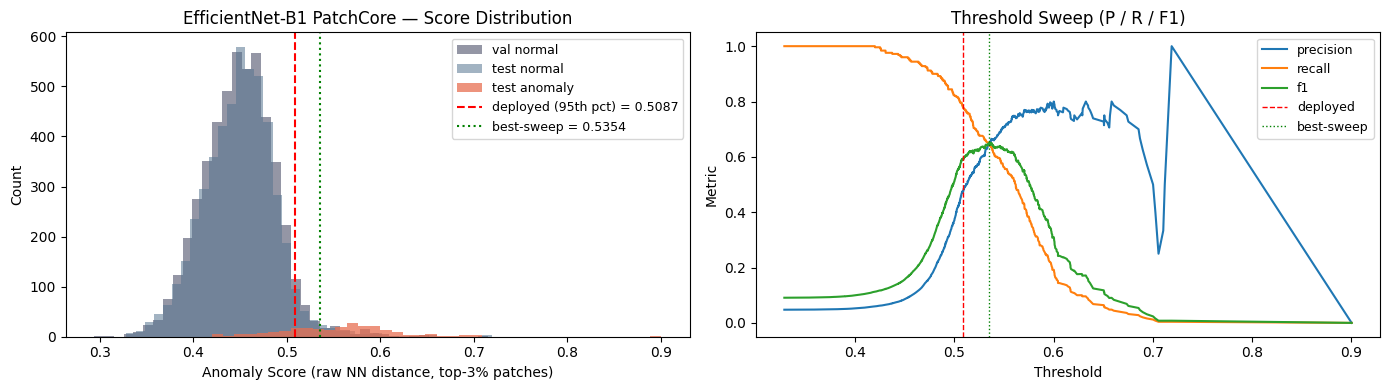

Saved: C:\Users\User\Desktop\Term 8\Deep Learning\Project\DeepLearning-Group8\experiments\anomaly_detection\patchcore\efficientnet_b1\x240\main_one_layer\artifacts\patchcore_efficientnet_b1_one_layer\plots\benchmark_distribution_sweep.png


,pred_normal,pred_anomaly
true_normal,4785,215
true_anomaly,55,195


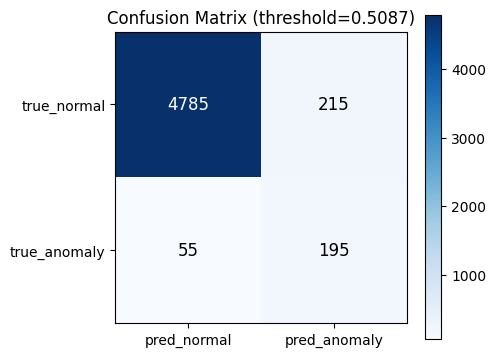

Saved: C:\Users\User\Desktop\Term 8\Deep Learning\Project\DeepLearning-Group8\experiments\anomaly_detection\patchcore\efficientnet_b1\x240\main_one_layer\artifacts\patchcore_efficientnet_b1_one_layer\plots\benchmark_distribution_sweep_confusion.png


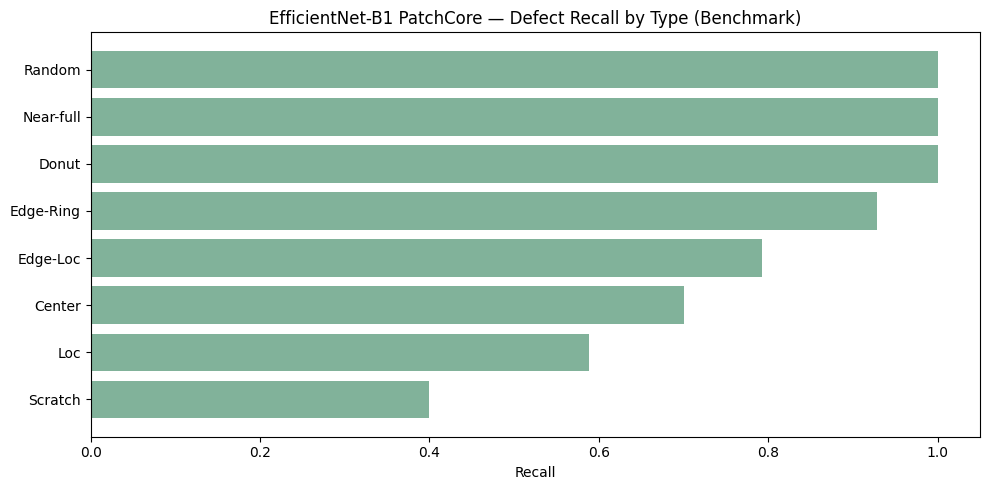

Saved: C:\Users\User\Desktop\Term 8\Deep Learning\Project\DeepLearning-Group8\experiments\anomaly_detection\patchcore\efficientnet_b1\x240\main_one_layer\artifacts\patchcore_efficientnet_b1_one_layer\plots\benchmark_defect_breakdown.png
Saved: C:\Users\User\Desktop\Term 8\Deep Learning\Project\DeepLearning-Group8\experiments\anomaly_detection\patchcore\efficientnet_b1\x240\main_one_layer\artifacts\patchcore_efficientnet_b1_one_layer\results\main_phase_manifest.json


In [23]:
# ── Benchmark plots, confusion matrix and manifest ────────────────────────────
# Regenerates all plots in artifacts/plots/ from the result dict.
# Works with both RETRAIN=True and RETRAIN=False.

import shutil
import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix as sk_confusion_matrix

paths      = artifact_layout(output_dir)
plots_dir  = paths["plots_dir"]
eval_dir   = paths["evaluation_dir"]
plots_dir.mkdir(parents=True, exist_ok=True)
eval_dir.mkdir(parents=True, exist_ok=True)

_val_df   = result["val_scores_df"]
_test_df  = result["test_scores_df"]
_sweep_df = result["threshold_sweep_df"]
_bd_df    = result["defect_breakdown_df"]
_summary  = result["summary"]
_threshold   = float(_summary["threshold"])
_best_thresh = float(_summary["best_sweep_threshold"])

_val_normal   = _val_df.loc[_val_df["is_anomaly"] == 0, "score"].to_numpy()
_test_normal  = _test_df.loc[_test_df["is_anomaly"] == 0, "score"].to_numpy()
_test_anomaly = _test_df.loc[_test_df["is_anomaly"] == 1, "score"].to_numpy()

# ── Score distribution + threshold sweep ─────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(14, 4))

axes[0].hist(_val_normal,   bins=40, alpha=0.55, color="#3d405b", label="val normal")
axes[0].hist(_test_normal,  bins=40, alpha=0.55, color="#577590", label="test normal")
axes[0].hist(_test_anomaly, bins=40, alpha=0.75, color="#e76f51", label="test anomaly")
axes[0].axvline(_threshold,   color="red",   linestyle="--", linewidth=1.5,
                label=f"deployed (95th pct) = {_threshold:.4f}")
axes[0].axvline(_best_thresh, color="green", linestyle=":",  linewidth=1.5,
                label=f"best-sweep = {_best_thresh:.4f}")
axes[0].set_xlabel("Anomaly Score (raw NN distance, top-3% patches)")
axes[0].set_ylabel("Count")
axes[0].set_title("EfficientNet-B1 PatchCore \u2014 Score Distribution")
axes[0].legend(fontsize=9)

_sweep_sorted = _sweep_df.sort_values("threshold")
axes[1].plot(_sweep_sorted["threshold"], _sweep_sorted["precision"], label="precision")
axes[1].plot(_sweep_sorted["threshold"], _sweep_sorted["recall"],    label="recall")
axes[1].plot(_sweep_sorted["threshold"], _sweep_sorted["f1"],        label="f1")
axes[1].axvline(_threshold,   color="red",   linestyle="--", linewidth=1, label="deployed")
axes[1].axvline(_best_thresh, color="green", linestyle=":",  linewidth=1, label="best-sweep")
axes[1].set_xlabel("Threshold")
axes[1].set_ylabel("Metric")
axes[1].set_title("Threshold Sweep (P / R / F1)")
axes[1].legend(fontsize=9)

plt.tight_layout()
fig.savefig(plots_dir / "benchmark_distribution_sweep.png", dpi=200, bbox_inches="tight")
plt.show()
plt.close(fig)
print(f"Saved: {plots_dir / 'benchmark_distribution_sweep.png'}")

# ── Confusion matrix CSV + heatmap ───────────────────────────────────────────
_labels = _test_df["is_anomaly"].to_numpy()
_scores = _test_df["score"].to_numpy()
_preds  = (_scores >= _threshold).astype(int)
_cm     = sk_confusion_matrix(_labels, _preds)
tn, fp, fn, tp = _cm.ravel()

cm_df = pd.DataFrame(
    [[int(tn), int(fp)], [int(fn), int(tp)]],
    index=["true_normal", "true_anomaly"],
    columns=["pred_normal", "pred_anomaly"],
)
cm_df.to_csv(eval_dir / "confusion_matrix.csv")
display(cm_df)

fig, ax = plt.subplots(figsize=(5, 4))
im = ax.imshow(cm_df.values, cmap="Blues")
ax.set_xticks([0, 1]); ax.set_xticklabels(["pred_normal", "pred_anomaly"])
ax.set_yticks([0, 1]); ax.set_yticklabels(["true_normal", "true_anomaly"])
_max_val = cm_df.values.max()
for i in range(2):
    for j in range(2):
        v = cm_df.values[i, j]
        ax.text(j, i, str(v), ha="center", va="center",
                color="white" if v > _max_val / 2 else "black", fontsize=12)
ax.set_title(f"Confusion Matrix (threshold={_threshold:.4f})")
plt.colorbar(im, ax=ax)
plt.tight_layout()
fig.savefig(plots_dir / "benchmark_distribution_sweep_confusion.png", dpi=200, bbox_inches="tight")
plt.show()
plt.close(fig)
print(f"Saved: {plots_dir / 'benchmark_distribution_sweep_confusion.png'}")

# ── Defect breakdown bar chart ────────────────────────────────────────────────
fig, ax = plt.subplots(figsize=(10, 5))
_bd_sorted = _bd_df.sort_values("recall", ascending=False)
ax.barh(_bd_sorted["defect_type"], _bd_sorted["recall"], color="#81b29a")
ax.set_xlim(0.0, 1.05)
ax.invert_yaxis()
ax.set_xlabel("Recall")
ax.set_title("EfficientNet-B1 PatchCore \u2014 Defect Recall by Type (Benchmark)")
plt.tight_layout()
fig.savefig(plots_dir / "benchmark_defect_breakdown.png", dpi=200, bbox_inches="tight")
plt.show()
plt.close(fig)
print(f"Saved: {plots_dir / 'benchmark_defect_breakdown.png'}")

# ── Main-phase manifest ───────────────────────────────────────────────────────
manifest = {
    "output_dir": str(output_dir),
    "best_variant": _summary.get("name", _summary.get("variant", "")),
    "phase": "main",
    "auroc":     float(_summary["auroc"]),
    "auprc":     float(_summary["auprc"]),
    "f1":        float(_summary["f1"]),
    "precision": float(_summary["precision"]),
    "recall":    float(_summary["recall"]),
    "threshold": float(_threshold),
}
manifest_path = paths["results_dir"] / "main_phase_manifest.json"
manifest_path.write_text(json.dumps(manifest, indent=2), encoding="utf-8")
print(f"Saved: {manifest_path}")


,name,protocol,threshold_policy,threshold_quantile,threshold,precision,recall,f1,auroc,auprc,best_sweep_threshold,best_sweep_precision,best_sweep_recall,best_sweep_f1,predicted_anomalies,counts
0,PatchCore-EfficientNetB1-OneLayer-x240,holdout70k_3p5k,val_normal_quantile_raw,0.95,0.508699,0.465778,0.828286,0.596257,0.953229,0.655528,0.532987,0.639948,0.704857,0.670836,6224,"{'train_normal': 40000, 'val_normal': 5000, 't..."


,defect_type,count,detected,mean_score,median_score,missed,recall
0,Scratch,158,82,0.527823,0.512305,76,0.518987
1,Loc,488,299,0.529622,0.528261,189,0.612705
2,Center,547,404,0.536426,0.530414,143,0.738574
3,Edge-Loc,723,582,0.551954,0.544751,141,0.804979
4,Edge-Ring,1364,1312,0.583743,0.580701,52,0.961877
5,Random,125,125,0.638940,0.637923,0,1.000000
6,Donut,78,78,0.604359,0.611844,0,1.000000
7,Near-full,17,17,0.660329,0.654661,0,1.000000


,pred_normal,pred_anomaly
true_normal,66675,3325
true_anomaly,601,2899


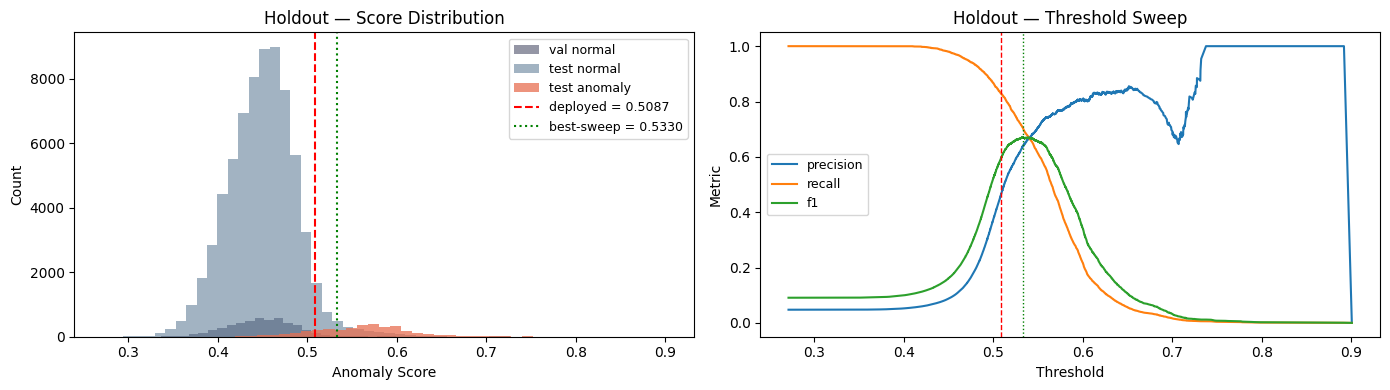

Saved: C:\Users\User\Desktop\Term 8\Deep Learning\Project\DeepLearning-Group8\experiments\anomaly_detection\patchcore\efficientnet_b1\x240\main_one_layer\artifacts\patchcore_efficientnet_b1_one_layer\results\holdout70k_3p5k\plots\holdout_distribution_sweep.png


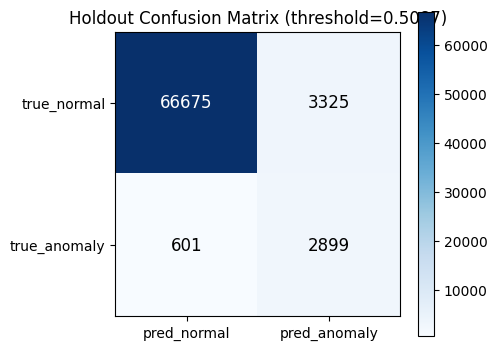

Saved: C:\Users\User\Desktop\Term 8\Deep Learning\Project\DeepLearning-Group8\experiments\anomaly_detection\patchcore\efficientnet_b1\x240\main_one_layer\artifacts\patchcore_efficientnet_b1_one_layer\results\holdout70k_3p5k\plots\holdout_distribution_sweep_confusion.png


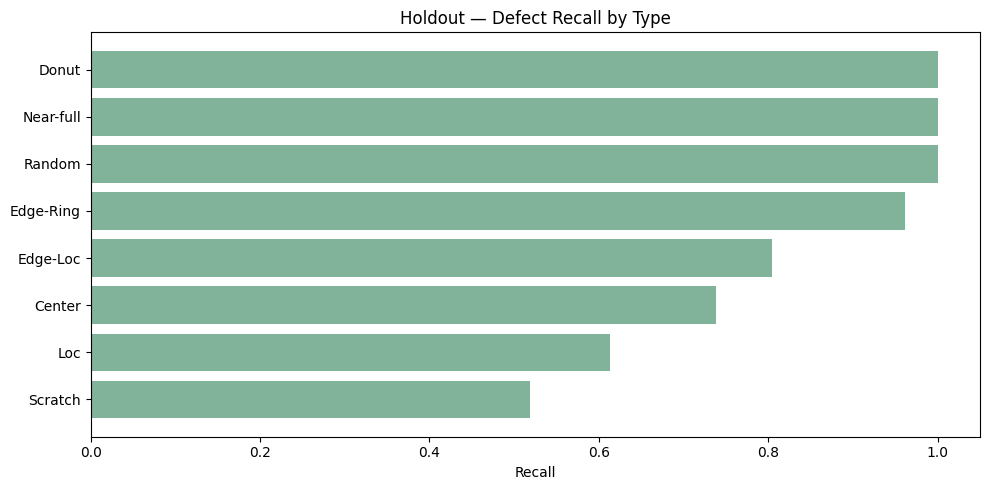

Saved: C:\Users\User\Desktop\Term 8\Deep Learning\Project\DeepLearning-Group8\experiments\anomaly_detection\patchcore\efficientnet_b1\x240\main_one_layer\artifacts\patchcore_efficientnet_b1_one_layer\results\holdout70k_3p5k\plots\holdout_defect_breakdown.png
Holdout plots saved to C:\Users\User\Desktop\Term 8\Deep Learning\Project\DeepLearning-Group8\experiments\anomaly_detection\patchcore\efficientnet_b1\x240\main_one_layer\artifacts\patchcore_efficientnet_b1_one_layer\results\holdout70k_3p5k\plots


In [24]:
# ── Holdout evaluation / plot generation ──────────────────────────────────────
# RUN_HOLDOUT_EVALUATION=True  → rebuild holdout split and re-score (RAM-heavy).
# RUN_HOLDOUT_EVALUATION=False → load pre-saved holdout CSVs and regenerate plots.

RUN_HOLDOUT_EVALUATION = False

paths             = artifact_layout(output_dir)
holdout_dir       = paths["holdout_dir"]
holdout_eval_dir  = paths["holdout_eval_dir"]
holdout_plots_dir = holdout_dir / "plots"
holdout_plots_dir.mkdir(parents=True, exist_ok=True)

if RUN_HOLDOUT_EVALUATION:
    holdout_config = copy.deepcopy(CONFIG)
    holdout_config["split"]["test_normal_count"] = 70_000
    holdout_config["split"]["test_defect_fraction_of_test_normals"] = 3_500 / 70_000
    holdout_dataset = build_split_from_raw(holdout_config)

    display(pd.DataFrame([
        {"split": "train", "count": len(holdout_dataset["train_y"]), "anomalies": int((holdout_dataset["train_y"] == 1).sum())},
        {"split": "val",   "count": len(holdout_dataset["val_y"]),   "anomalies": int((holdout_dataset["val_y"] == 1).sum())},
        {"split": "test",  "count": len(holdout_dataset["test_y"]),  "anomalies": int((holdout_dataset["test_y"] == 1).sum())},
    ]))

    device = resolve_device(str(holdout_config["model"]["device"]))
    holdout_loaders = make_loaders(holdout_dataset, holdout_config, device)
    holdout_model = EfficientNetB1OneLayerPatchCoreModel(
        model_input_size=int(holdout_config["model"]["model_input_size"]),
        feature_idx=int(holdout_config["model"]["effnet_feature_idx"]),
        patch_embed_dim=int(holdout_config["model"]["patch_embed_dim"]),
        topk_ratio=float(holdout_config["model"]["topk_patch_ratio"]),
        nn_k=int(holdout_config["model"]["patchcore_nn_k"]),
        query_chunk_size=int(holdout_config["model"]["score_chunk"]),
        amp_enabled=bool(holdout_config["model"]["amp"]),
    ).to(device).eval()

    checkpoint_state = result["checkpoint"]["model_state_dict"]
    if "memory_bank" in checkpoint_state:
        holdout_model.set_memory_bank(checkpoint_state["memory_bank"])
        holdout_model.load_state_dict(checkpoint_state, strict=False)
    else:
        holdout_model.load_state_dict(checkpoint_state)

    holdout_val_scores_df  = collect_scores(holdout_model, holdout_loaders["val"],  device, desc="score_val_holdout")
    holdout_test_scores_df = collect_scores(holdout_model, holdout_loaders["test"], device, desc="score_test_holdout")

    holdout_threshold = float(np.quantile(
        holdout_val_scores_df.loc[holdout_val_scores_df["is_anomaly"] == 0, "score"].to_numpy(),
        float(holdout_config["scoring"]["threshold_quantile"]),
    ))
    holdout_labels = holdout_test_scores_df["is_anomaly"].to_numpy()
    holdout_scores = holdout_test_scores_df["score"].to_numpy()
    holdout_metrics = summarize_threshold_metrics(holdout_labels, holdout_scores, holdout_threshold)
    holdout_threshold_sweep_df, holdout_best_sweep = sweep_threshold_metrics(holdout_labels, holdout_scores)
    holdout_defect_breakdown_df = build_defect_breakdown(
        holdout_dataset["test_defect_types"], holdout_labels, holdout_scores, holdout_threshold,
    )

    holdout_summary = {
        "name": result["summary"]["name"],
        "protocol": "holdout70k_3p5k",
        "threshold_policy": "val_normal_quantile_raw",
        "threshold_quantile": float(holdout_config["scoring"]["threshold_quantile"]),
        "threshold": float(holdout_threshold),
        "precision": float(holdout_metrics["precision"]),
        "recall":    float(holdout_metrics["recall"]),
        "f1":        float(holdout_metrics["f1"]),
        "auroc":     float(holdout_metrics["auroc"]),
        "auprc":     float(holdout_metrics["auprc"]),
        "best_sweep_threshold": float(holdout_best_sweep["threshold"]),
        "best_sweep_precision": float(holdout_best_sweep["precision"]),
        "best_sweep_recall":    float(holdout_best_sweep["recall"]),
        "best_sweep_f1":        float(holdout_best_sweep["f1"]),
        "predicted_anomalies":  int(holdout_metrics["predicted_anomalies"]),
        "counts": {
            "train_normal": int((holdout_dataset["train_y"] == 0).sum()),
            "val_normal":   int((holdout_dataset["val_y"]   == 0).sum()),
            "test_normal":  int((holdout_dataset["test_y"]  == 0).sum()),
            "test_anomaly": int((holdout_dataset["test_y"]  == 1).sum()),
        },
    }

    holdout_eval_dir.mkdir(parents=True, exist_ok=True)
    holdout_val_scores_df.to_csv(holdout_eval_dir / "val_scores.csv", index=False)
    holdout_test_scores_df.to_csv(holdout_eval_dir / "test_scores.csv", index=False)
    holdout_threshold_sweep_df.to_csv(holdout_eval_dir / "threshold_sweep.csv", index=False)
    holdout_defect_breakdown_df.to_csv(holdout_eval_dir / "defect_breakdown.csv", index=False)
    pd.DataFrame([holdout_summary]).to_csv(holdout_dir / "summary.csv", index=False)
    (holdout_dir / "summary.json").write_text(json.dumps(holdout_summary, indent=2), encoding="utf-8")

    display(pd.DataFrame([holdout_summary]))
    display(holdout_defect_breakdown_df)
    print(f"Saved holdout evaluation artifacts to {holdout_dir}")

else:
    # Load pre-saved holdout artifacts if they exist and regenerate plots.
    _h_summary_path = holdout_dir / "summary.json"
    _h_test_csv     = holdout_eval_dir / "test_scores.csv"
    _h_val_csv      = holdout_eval_dir / "val_scores.csv"
    _h_sweep_csv    = holdout_eval_dir / "threshold_sweep.csv"
    _h_bd_csv       = holdout_eval_dir / "defect_breakdown.csv"

    if not _h_summary_path.exists() or not _h_test_csv.exists():
        print(
            "Holdout artifacts not found. Either:\n"
            "  (a) set RUN_HOLDOUT_EVALUATION=True to run the full evaluation, or\n"
            "  (b) ensure pre-generated holdout artifacts exist in:\n"
            f"      {holdout_dir}"
        )
    else:
        from sklearn.metrics import confusion_matrix as sk_confusion_matrix

        holdout_summary        = json.loads(_h_summary_path.read_text(encoding="utf-8"))
        holdout_val_scores_df  = pd.read_csv(_h_val_csv)
        holdout_test_scores_df = pd.read_csv(_h_test_csv)
        holdout_threshold_sweep_df  = pd.read_csv(_h_sweep_csv)  if _h_sweep_csv.exists()  else None
        holdout_defect_breakdown_df = pd.read_csv(_h_bd_csv)     if _h_bd_csv.exists()     else None

        holdout_threshold  = float(holdout_summary["threshold"])
        holdout_labels_arr = holdout_test_scores_df["is_anomaly"].to_numpy()
        holdout_scores_arr = holdout_test_scores_df["score"].to_numpy()
        holdout_preds      = (holdout_scores_arr >= holdout_threshold).astype(int)

        display(pd.DataFrame([holdout_summary]))
        if holdout_defect_breakdown_df is not None:
            display(holdout_defect_breakdown_df)

        # Confusion matrix CSV
        _h_cm = sk_confusion_matrix(holdout_labels_arr, holdout_preds)
        tn, fp, fn, tp = _h_cm.ravel()
        h_cm_df = pd.DataFrame(
            [[int(tn), int(fp)], [int(fn), int(tp)]],
            index=["true_normal", "true_anomaly"],
            columns=["pred_normal", "pred_anomaly"],
        )
        h_cm_df.to_csv(holdout_eval_dir / "confusion_matrix.csv")
        display(h_cm_df)

        # ── Score distribution + sweep ────────────────────────────────────────
        _h_val_n  = holdout_val_scores_df.loc[holdout_val_scores_df["is_anomaly"] == 0, "score"].to_numpy()
        _h_test_n = holdout_test_scores_df.loc[holdout_test_scores_df["is_anomaly"] == 0, "score"].to_numpy()
        _h_test_a = holdout_test_scores_df.loc[holdout_test_scores_df["is_anomaly"] == 1, "score"].to_numpy()
        _h_best   = float(holdout_summary.get("best_sweep_threshold", holdout_threshold))

        fig, axes = plt.subplots(1, 2, figsize=(14, 4))
        axes[0].hist(_h_val_n,  bins=40, alpha=0.55, color="#3d405b", label="val normal")
        axes[0].hist(_h_test_n, bins=40, alpha=0.55, color="#577590", label="test normal")
        axes[0].hist(_h_test_a, bins=40, alpha=0.75, color="#e76f51", label="test anomaly")
        axes[0].axvline(holdout_threshold, color="red",   linestyle="--", linewidth=1.5,
                        label=f"deployed = {holdout_threshold:.4f}")
        axes[0].axvline(_h_best,           color="green", linestyle=":",  linewidth=1.5,
                        label=f"best-sweep = {_h_best:.4f}")
        axes[0].set_xlabel("Anomaly Score")
        axes[0].set_ylabel("Count")
        axes[0].set_title("Holdout \u2014 Score Distribution")
        axes[0].legend(fontsize=9)

        if holdout_threshold_sweep_df is not None:
            _hs = holdout_threshold_sweep_df.sort_values("threshold")
            axes[1].plot(_hs["threshold"], _hs["precision"], label="precision")
            axes[1].plot(_hs["threshold"], _hs["recall"],    label="recall")
            axes[1].plot(_hs["threshold"], _hs["f1"],        label="f1")
            axes[1].axvline(holdout_threshold, color="red",   linestyle="--", linewidth=1)
            axes[1].axvline(_h_best,           color="green", linestyle=":",  linewidth=1)
            axes[1].set_xlabel("Threshold")
            axes[1].set_ylabel("Metric")
            axes[1].set_title("Holdout \u2014 Threshold Sweep")
            axes[1].legend(fontsize=9)

        plt.tight_layout()
        fig.savefig(holdout_plots_dir / "holdout_distribution_sweep.png", dpi=200, bbox_inches="tight")
        plt.show()
        plt.close(fig)
        print(f"Saved: {holdout_plots_dir / 'holdout_distribution_sweep.png'}")

        # ── Confusion matrix heatmap ──────────────────────────────────────────
        fig, ax = plt.subplots(figsize=(5, 4))
        im = ax.imshow(h_cm_df.values, cmap="Blues")
        ax.set_xticks([0, 1]); ax.set_xticklabels(["pred_normal", "pred_anomaly"])
        ax.set_yticks([0, 1]); ax.set_yticklabels(["true_normal", "true_anomaly"])
        _hmax = h_cm_df.values.max()
        for i in range(2):
            for j in range(2):
                v = h_cm_df.values[i, j]
                ax.text(j, i, str(v), ha="center", va="center",
                        color="white" if v > _hmax / 2 else "black", fontsize=12)
        ax.set_title(f"Holdout Confusion Matrix (threshold={holdout_threshold:.4f})")
        plt.colorbar(im, ax=ax)
        plt.tight_layout()
        fig.savefig(holdout_plots_dir / "holdout_distribution_sweep_confusion.png", dpi=200, bbox_inches="tight")
        plt.show()
        plt.close(fig)
        print(f"Saved: {holdout_plots_dir / 'holdout_distribution_sweep_confusion.png'}")

        # ── Defect breakdown bar chart ─────────────────────────────────────────
        if holdout_defect_breakdown_df is not None:
            fig, ax = plt.subplots(figsize=(10, 5))
            _hbd = holdout_defect_breakdown_df.sort_values("recall", ascending=False)
            ax.barh(_hbd["defect_type"], _hbd["recall"], color="#81b29a")
            ax.set_xlim(0.0, 1.05)
            ax.invert_yaxis()
            ax.set_xlabel("Recall")
            ax.set_title("Holdout \u2014 Defect Recall by Type")
            plt.tight_layout()
            fig.savefig(holdout_plots_dir / "holdout_defect_breakdown.png", dpi=200, bbox_inches="tight")
            plt.show()
            plt.close(fig)
            print(f"Saved: {holdout_plots_dir / 'holdout_defect_breakdown.png'}")

        print(f"Holdout plots saved to {holdout_plots_dir}")


,threshold_quantile,umap_knn_threshold,counts.train_reference,counts.val_total,counts.val_normal,counts.val_anomaly,counts.test_total,counts.test_normal,counts.test_anomaly,plot_counts.train_reference,...,umap_knn_metrics.confusion_matrix,umap_knn_best_threshold_sweep.threshold,umap_knn_best_threshold_sweep.precision,umap_knn_best_threshold_sweep.recall,umap_knn_best_threshold_sweep.f1,umap_knn_best_threshold_sweep.predicted_anomalies,outputs.points_csv,outputs.split_plot,outputs.score_plot,outputs.threshold_sweep_csv
0,0.95,0.264473,5000,5000,5000,0,5250,5000,250,5000,...,"[[4747, 253], [232, 18]]",0.196737,0.065934,0.192,0.09816,727,/__modal/volumes/vo-6vubjI2ebQVRDFhPA7gG0n/pat...,/__modal/volumes/vo-6vubjI2ebQVRDFhPA7gG0n/pat...,/__modal/volumes/vo-6vubjI2ebQVRDFhPA7gG0n/pat...,/__modal/volumes/vo-6vubjI2ebQVRDFhPA7gG0n/pat...


Loaded reference-fit UMAP points from C:\Users\User\Desktop\Term 8\Deep Learning\Project\DeepLearning-Group8\experiments\anomaly_detection\patchcore\efficientnet_b1\x240\main_one_layer\artifacts\patchcore_efficientnet_b1_one_layer\results\umap\reference_fit\umap_points.csv


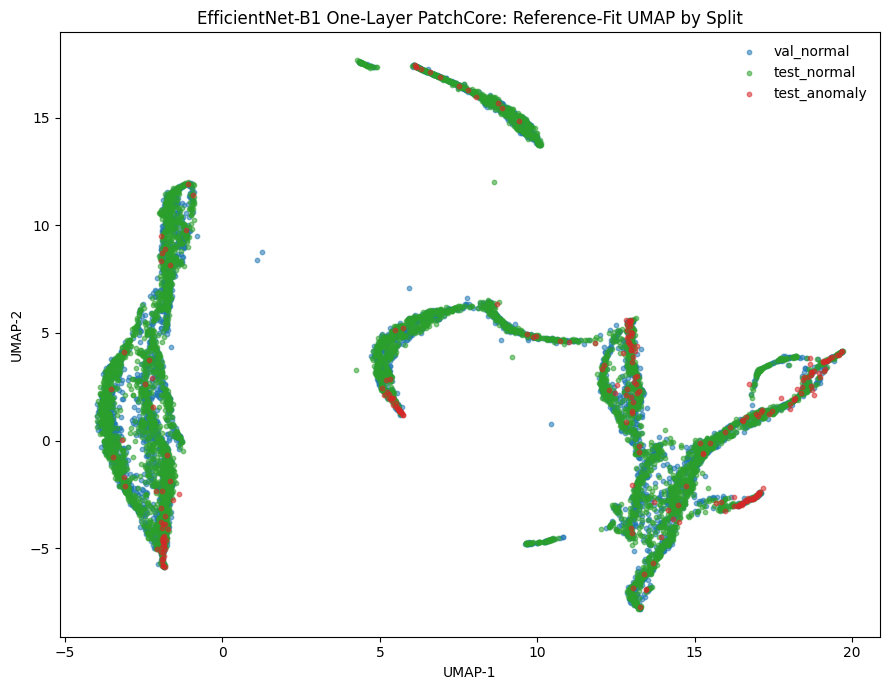

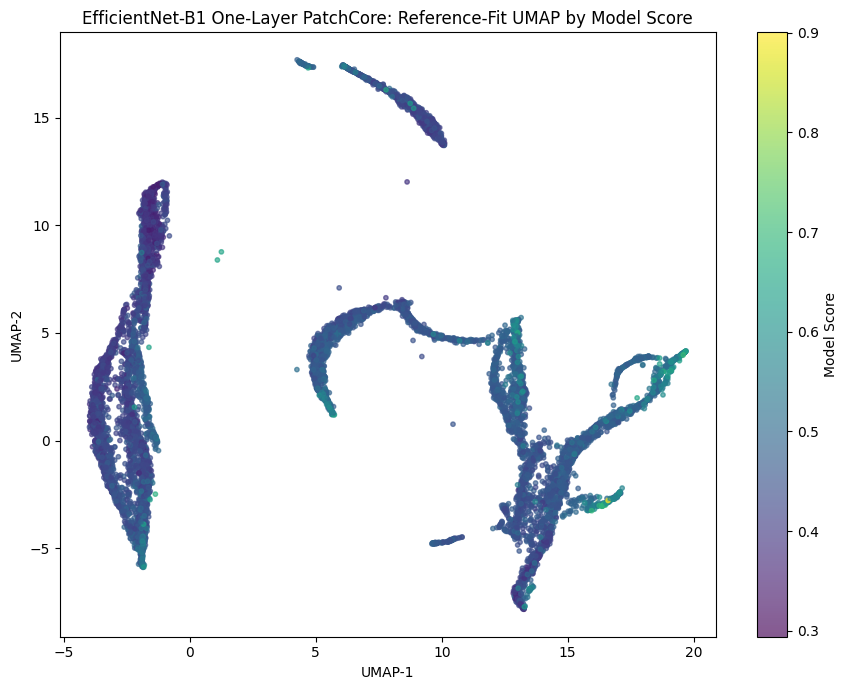

Reference-fit UMAP plots saved to C:\Users\User\Desktop\Term 8\Deep Learning\Project\DeepLearning-Group8\experiments\anomaly_detection\patchcore\efficientnet_b1\x240\main_one_layer\artifacts\patchcore_efficientnet_b1_one_layer\results\umap\reference_fit\plots


In [25]:
# ── REGENERATE_UMAP FLAG ──────────────────────────────────────────────────────
# True  → collect embeddings from the loaded model and recompute the reference-fit UMAP.
# False → load previously saved embeddings and UMAP summary from disk; skip recomputation.
REGENERATE_UMAP = False
# ─────────────────────────────────────────────────────────────────────────────

import matplotlib.pyplot as plt
import umap.umap_ as umap

evaluation_dir = artifact_layout(output_dir)["umap_reference_dir"]
plots_dir = evaluation_dir / "plots"
plots_dir.mkdir(parents=True, exist_ok=True)


def collect_embeddings_and_scores(model, loader, device, desc):
    embeddings_all, labels_all, scores_all = [], [], []
    model.eval()
    progress = tqdm(loader, desc=desc, total=len(loader), leave=True)
    with torch.inference_mode():
        for inputs, labels in progress:
            inputs = inputs.to(device, non_blocking=device.type == "cuda")
            patch_embeddings = model.patch_embeddings(inputs)
            image_embeddings = patch_embeddings.mean(dim=1)
            patch_scores     = model.nearest_patch_distances(patch_embeddings)
            scores           = model.reduce_patch_distances(patch_scores)
            embeddings_all.append(image_embeddings.cpu().numpy())
            labels_all.extend(labels.cpu().tolist())
            scores_all.extend(scores.cpu().tolist())
    return (
        np.concatenate(embeddings_all, axis=0),
        np.asarray(labels_all, dtype=np.int64),
        np.asarray(scores_all, dtype=np.float32),
    )


if REGENERATE_UMAP:
    device      = resolve_device(str(CONFIG["model"]["device"]))
    main_loaders = make_loaders(dataset, CONFIG, device)

    umap_model = EfficientNetB1OneLayerPatchCoreModel(
        model_input_size=int(CONFIG["model"]["model_input_size"]),
        feature_idx=int(CONFIG["model"]["effnet_feature_idx"]),
        patch_embed_dim=int(CONFIG["model"]["patch_embed_dim"]),
        topk_ratio=float(CONFIG["model"]["topk_patch_ratio"]),
        nn_k=int(CONFIG["model"]["patchcore_nn_k"]),
        query_chunk_size=int(CONFIG["model"]["score_chunk"]),
        amp_enabled=bool(CONFIG["model"]["amp"]),
    ).to(device).eval()

    umap_state = result["checkpoint"]["model_state_dict"]
    if "memory_bank" in umap_state:
        umap_model.set_memory_bank(umap_state["memory_bank"])
        umap_model.load_state_dict(umap_state, strict=False)
    else:
        umap_model.load_state_dict(umap_state)

    train_embeddings, train_labels, _          = collect_embeddings_and_scores(umap_model, main_loaders["train"], device, "umap_train")
    val_embeddings,   val_labels,   val_scores  = collect_embeddings_and_scores(umap_model, main_loaders["val"],   device, "umap_val")
    test_embeddings,  test_labels,  test_scores = collect_embeddings_and_scores(umap_model, main_loaders["test"],  device, "umap_test")

    np.save(evaluation_dir / "train_embeddings.npy", train_embeddings)
    np.save(evaluation_dir / "val_embeddings.npy",   val_embeddings)
    np.save(evaluation_dir / "test_embeddings.npy",  test_embeddings)
    np.save(evaluation_dir / "train_labels.npy",     train_labels)
    np.save(evaluation_dir / "val_labels.npy",       val_labels)
    np.save(evaluation_dir / "test_labels.npy",      test_labels)
    np.save(evaluation_dir / "val_scores.npy",       val_scores)
    np.save(evaluation_dir / "test_scores.npy",      test_scores)

    umap_bundle = export_reference_umap_bundle(
        output_dir=evaluation_dir,
        umap_module=umap,
        train_normal_embeddings=train_embeddings,
        val_embeddings=val_embeddings,
        val_labels=val_labels,
        test_embeddings=test_embeddings,
        test_labels=test_labels,
        val_model_scores=val_scores,
        test_model_scores=test_scores,
        threshold_quantile=float(CONFIG["scoring"]["threshold_quantile"]),
        random_state=42,
        pca_components=50,
        n_neighbors=15,
        min_dist=0.1,
        knn_k=15,
        metric="euclidean",
        max_train_reference=5000,
        max_val_normal=5000,
        max_test_normal=5000,
        max_test_anomaly=250,
        title_prefix="EfficientNet-B1 One-Layer PatchCore",
        points_filename="umap_points.csv",
        split_plot_filename="plots/umap_by_split.png",
        score_plot_filename="plots/umap_by_score.png",
        summary_filename="umap_summary.json",
        sweep_filename="umap_knn_threshold_sweep.csv",
    )
    display(pd.json_normalize(umap_bundle["summary"], sep="."))
    print(f"Saved reference-fit UMAP artifacts to {evaluation_dir}")

else:
    # Load from saved umap_points.csv — raw embeddings are not persisted to disk.
    # Plots are regenerated from the fitted 2D coordinates in the CSV.
    points_path = evaluation_dir / "umap_points.csv"
    if not points_path.exists():
        raise FileNotFoundError(
            f"UMAP points CSV not found at {points_path}.\n"
            "Set REGENERATE_UMAP=True to collect embeddings and compute UMAP from scratch."
        )

    ref_df = pd.read_csv(points_path)
    summary_path = evaluation_dir / "umap_summary.json"
    if summary_path.exists():
        display(pd.json_normalize(json.loads(summary_path.read_text(encoding="utf-8")), sep="."))
    print(f"Loaded reference-fit UMAP points from {points_path}")

    _group_colors = {
        "val_normal":  "#1f77b4",
        "test_normal": "#2ca02c",
        "test_anomaly": "#d62728",
    }
    _plot_df = ref_df[ref_df["split_label"].isin(_group_colors)]

    plt.figure(figsize=(9, 7))
    for group, color in _group_colors.items():
        subset = _plot_df[_plot_df["split_label"] == group]
        if len(subset):
            plt.scatter(subset["umap_1"], subset["umap_2"], s=10, alpha=0.55, label=group, c=color)
    plt.xlabel("UMAP-1")
    plt.ylabel("UMAP-2")
    plt.title("EfficientNet-B1 One-Layer PatchCore: Reference-Fit UMAP by Split")
    plt.legend(frameon=False)
    plt.tight_layout()
    plt.savefig(plots_dir / "umap_by_split.png", dpi=220, bbox_inches="tight")
    plt.show()

    plt.figure(figsize=(9, 7))
    _scatter = plt.scatter(
        _plot_df["umap_1"], _plot_df["umap_2"],
        c=_plot_df["model_score"], cmap="viridis", s=10, alpha=0.65,
    )
    plt.xlabel("UMAP-1")
    plt.ylabel("UMAP-2")
    plt.title("EfficientNet-B1 One-Layer PatchCore: Reference-Fit UMAP by Model Score")
    plt.colorbar(_scatter, label="Model Score")
    plt.tight_layout()
    plt.savefig(plots_dir / "umap_by_score.png", dpi=220, bbox_inches="tight")
    plt.show()

    print(f"Reference-fit UMAP plots saved to {plots_dir}")

,name,note,counts.val_normal,counts.test_normal,counts.test_anomaly,umap_params.random_state,umap_params.pca_components,umap_params.n_neighbors,umap_params.min_dist
0,PatchCore-EfficientNetB1-OneLayer-x240,Comparison-only joint-fit UMAP. Test points ar...,5000,5000,250,42,50,15,0.1


Loaded joint-fit UMAP from C:\Users\User\Desktop\Term 8\Deep Learning\Project\DeepLearning-Group8\experiments\anomaly_detection\patchcore\efficientnet_b1\x240\main_one_layer\artifacts\patchcore_efficientnet_b1_one_layer\results\umap\joint_fit\umap_points.csv


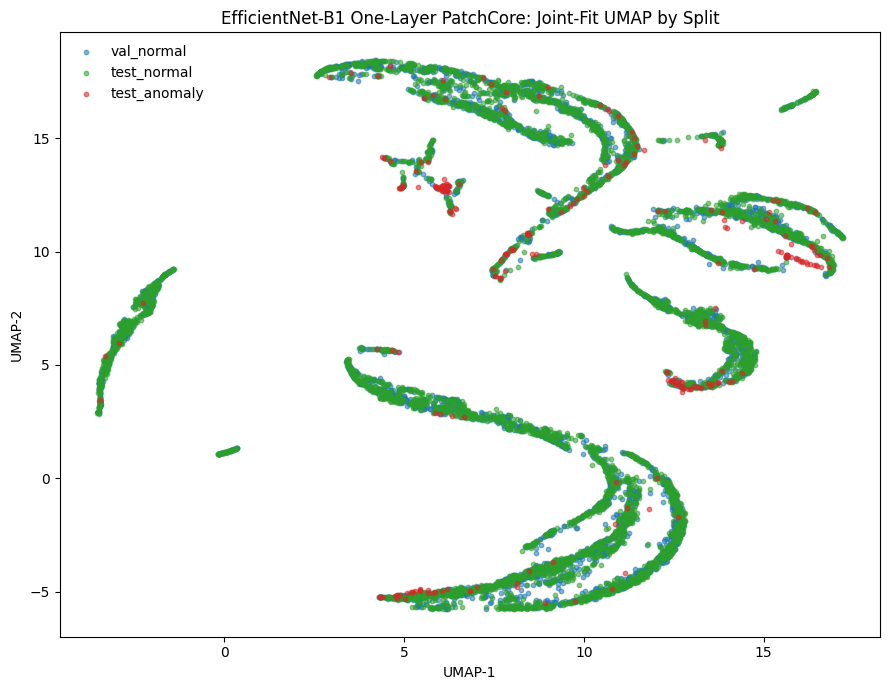

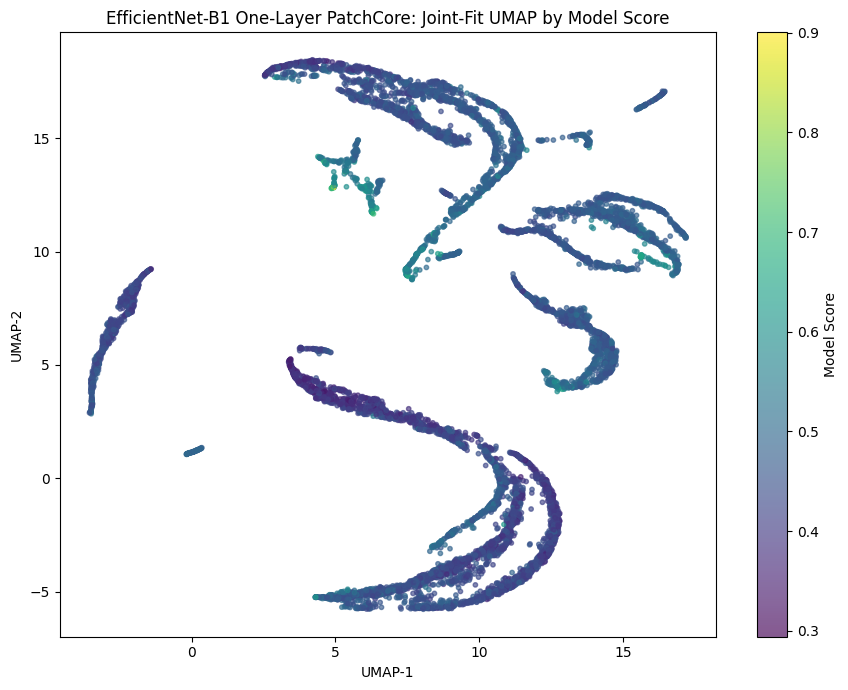

In [26]:
# Joint-fit UMAP: comparison-only view where val + test points jointly shape the 2D layout.
# Useful for visual inspection but less strict than the reference-fit UMAP above because
# test points influence the manifold itself.
# Controlled by REGENERATE_UMAP set in the reference-fit UMAP cell above.

joint_fit_dir       = artifact_layout(output_dir)["umap_joint_dir"]
joint_fit_plots_dir = joint_fit_dir / "plots"
joint_fit_plots_dir.mkdir(parents=True, exist_ok=True)

joint_df = None  # populated below in either branch

if REGENERATE_UMAP:
    # val_embeddings / test_embeddings / val_labels / test_labels / val_scores / test_scores
    # are all already in scope from the reference-fit UMAP cell above.
    joint_embeddings   = np.concatenate([val_embeddings, test_embeddings], axis=0)
    joint_groups       = np.concatenate([
        np.where(val_labels  == 0, "val_normal",  "val_anomaly"),
        np.where(test_labels == 0, "test_normal", "test_anomaly"),
    ])
    joint_is_anomaly   = np.concatenate([val_labels.astype(int),   test_labels.astype(int)],  axis=0)
    joint_model_scores = np.concatenate([val_scores.astype(float), test_scores.astype(float)], axis=0)

    joint_umap_input = joint_embeddings
    if joint_embeddings.shape[1] > 50:
        joint_pca        = PCA(n_components=min(50, joint_embeddings.shape[0], joint_embeddings.shape[1]), random_state=42)
        joint_umap_input = joint_pca.fit_transform(joint_embeddings)

    joint_reducer = umap.UMAP(n_components=2, n_neighbors=15, min_dist=0.1, metric="euclidean", random_state=42)
    joint_points  = joint_reducer.fit_transform(joint_umap_input)

    joint_df = pd.DataFrame({
        "group":       joint_groups,
        "is_anomaly":  joint_is_anomaly,
        "model_score": joint_model_scores,
        "umap1":       joint_points[:, 0],
        "umap2":       joint_points[:, 1],
    })
    joint_df.to_csv(joint_fit_dir / "umap_points.csv", index=False)

    joint_fit_summary = {
        "name": result["summary"]["name"],
        "note": "Comparison-only joint-fit UMAP. Test points are included when fitting the 2D manifold.",
        "counts": {
            "val_normal":  int((val_labels  == 0).sum()),
            "test_normal": int((test_labels == 0).sum()),
            "test_anomaly": int((test_labels == 1).sum()),
        },
        "umap_params": {"random_state": 42, "pca_components": 50, "n_neighbors": 15, "min_dist": 0.1},
    }
    (joint_fit_dir / "umap_summary.json").write_text(json.dumps(joint_fit_summary, indent=2), encoding="utf-8")
    display(pd.json_normalize(joint_fit_summary, sep="."))
    print(f"Saved joint-fit UMAP artifacts to {joint_fit_dir}")

else:
    # Load from the saved CSV produced during the last REGENERATE_UMAP=True run.
    joint_points_path = joint_fit_dir / "umap_points.csv"
    if not joint_points_path.exists():
        print(f"Joint-fit UMAP CSV not found at {joint_points_path}. Set REGENERATE_UMAP=True to generate it.")
    else:
        joint_df = pd.read_csv(joint_points_path)
        joint_summary_path = joint_fit_dir / "umap_summary.json"
        if joint_summary_path.exists():
            display(pd.json_normalize(json.loads(joint_summary_path.read_text(encoding="utf-8")), sep="."))
        print(f"Loaded joint-fit UMAP from {joint_points_path}")

# ── Plotting (runs in both branches if joint_df is available) ─────────────────
if joint_df is not None:
    plot_df = joint_df[joint_df["group"].isin(["val_normal", "test_normal", "test_anomaly"])]

    plt.figure(figsize=(9, 7))
    for group, color in [("val_normal", "#1f77b4"), ("test_normal", "#2ca02c"), ("test_anomaly", "#d62728")]:
        subset = plot_df[plot_df["group"] == group]
        if len(subset):
            plt.scatter(subset["umap1"], subset["umap2"], s=10, alpha=0.55, label=group, c=color)
    plt.xlabel("UMAP-1")
    plt.ylabel("UMAP-2")
    plt.title("EfficientNet-B1 One-Layer PatchCore: Joint-Fit UMAP by Split")
    plt.legend(frameon=False)
    plt.tight_layout()
    plt.savefig(joint_fit_plots_dir / "umap_by_split.png", dpi=220, bbox_inches="tight")
    plt.show()

    plt.figure(figsize=(9, 7))
    scatter = plt.scatter(plot_df["umap1"], plot_df["umap2"], c=plot_df["model_score"], cmap="viridis", s=10, alpha=0.65)
    plt.xlabel("UMAP-1")
    plt.ylabel("UMAP-2")
    plt.title("EfficientNet-B1 One-Layer PatchCore: Joint-Fit UMAP by Model Score")
    plt.colorbar(scatter, label="Model Score")
    plt.tight_layout()
    plt.savefig(joint_fit_plots_dir / "umap_by_score.png", dpi=220, bbox_inches="tight")
    plt.show()

In [27]:
# ── Copy UMAP plots to flat plots/ directory ──────────────────────────────────
# Copies the 4 canonical UMAP figures from their subdirectories into artifacts/plots/
# so that the flat plots/ folder holds all report-ready figures in one place.
# Safe to re-run: silently skips missing source files.

import shutil

paths              = artifact_layout(output_dir)
plots_dir          = paths["plots_dir"]
umap_reference_dir = paths["umap_reference_dir"]
umap_joint_dir     = paths["umap_joint_dir"]

umap_copies = [
    (umap_reference_dir / "plots" / "umap_by_split.png",  plots_dir / "umap_reference_by_split.png"),
    (umap_reference_dir / "plots" / "umap_by_score.png",  plots_dir / "umap_reference_by_score.png"),
    (umap_joint_dir     / "plots" / "umap_by_split.png",  plots_dir / "umap_joint_by_split.png"),
    (umap_joint_dir     / "plots" / "umap_by_score.png",  plots_dir / "umap_joint_by_score.png"),
]

for src_path, dst_path in umap_copies:
    if src_path.exists():
        shutil.copy2(src_path, dst_path)
        print(f"Copied -> {dst_path.relative_to(output_dir)}")
    else:
        print(f"[skip] source not found: {src_path}")


Copied -> plots\umap_reference_by_split.png
Copied -> plots\umap_reference_by_score.png
Copied -> plots\umap_joint_by_split.png
Copied -> plots\umap_joint_by_score.png


## UMAP Interpretation Summary

This helper reads the saved UMAP artifacts and prints a short interpretation summary. It is diagnostic only and does not change the report-comparable threshold or scores.


In [28]:
# UMAP interpretation helper: reads saved artifacts and prints a compact summary.
from pathlib import Path
import json
import numpy as np
import pandas as pd


def _safe_ratio(numerator, denominator):
    return float(numerator) / float(denominator) if float(denominator) != 0.0 else float("nan")


def _euclidean_xy(df: pd.DataFrame, origin_x: float, origin_y: float) -> np.ndarray:
    dx = df["umap_1"].to_numpy(dtype=float) - float(origin_x)
    dy = df["umap_2"].to_numpy(dtype=float) - float(origin_y)
    return np.sqrt(dx * dx + dy * dy)


evaluation_dir = artifact_layout(output_dir)["umap_reference_dir"]
points_path = evaluation_dir / "umap_points.csv"
summary_path = evaluation_dir / "umap_summary.json"

if not points_path.exists():
    raise FileNotFoundError(f"UMAP points not found: {points_path}. Run the UMAP export cell first.")

points_df = pd.read_csv(points_path)
summary = json.loads(summary_path.read_text(encoding="utf-8")) if summary_path.exists() else {}

val_normal = points_df[points_df["split_label"] == "val_normal"].copy()
test_normal = points_df[points_df["split_label"] == "test_normal"].copy()
test_anomaly = points_df[points_df["split_label"] == "test_anomaly"].copy()

if len(val_normal) == 0:
    raise ValueError("No val_normal rows found in umap_points.csv")

val_center_x = float(val_normal["umap_1"].mean())
val_center_y = float(val_normal["umap_2"].mean())
val_radius = _euclidean_xy(val_normal, val_center_x, val_center_y)
base_radius = float(np.percentile(val_radius, 95)) if len(val_radius) else float("nan")

normal_shift = float("nan")
anomaly_shift = float("nan")
normal_outside = float("nan")
anomaly_outside = float("nan")
score_overlap = float("nan")

if len(test_normal):
    test_normal_center_x = float(test_normal["umap_1"].mean())
    test_normal_center_y = float(test_normal["umap_2"].mean())
    normal_shift = _safe_ratio(np.hypot(test_normal_center_x - val_center_x, test_normal_center_y - val_center_y), base_radius)
    normal_outside = float((_euclidean_xy(test_normal, val_center_x, val_center_y) > base_radius).mean())

if len(test_anomaly):
    test_anomaly_center_x = float(test_anomaly["umap_1"].mean())
    test_anomaly_center_y = float(test_anomaly["umap_2"].mean())
    anomaly_shift = _safe_ratio(np.hypot(test_anomaly_center_x - val_center_x, test_anomaly_center_y - val_center_y), base_radius)
    anomaly_outside = float((_euclidean_xy(test_anomaly, val_center_x, val_center_y) > base_radius).mean())

if len(test_normal) and len(test_anomaly):
    normal_q90 = float(test_normal["model_score"].quantile(0.90))
    anomaly_q10 = float(test_anomaly["model_score"].quantile(0.10))
    score_overlap = normal_q90 - anomaly_q10

interpretation = []

if not np.isnan(normal_shift):
    if normal_shift <= 0.35:
        interpretation.append("test normals stay close to the validation-normal reference cloud")
    elif normal_shift <= 0.75:
        interpretation.append("test normals show a mild shift away from the validation-normal cloud")
    else:
        interpretation.append("test normals are noticeably shifted, so distribution drift is likely")

if not np.isnan(anomaly_outside):
    if anomaly_outside >= 0.75:
        interpretation.append("most anomalies land outside the normal reference radius, which is a strong separation sign")
    elif anomaly_outside >= 0.45:
        interpretation.append("anomalies are only partly separated; some defect modes still overlap normals")
    else:
        interpretation.append("many anomalies remain inside the normal cloud, so feature separation is weak")

if not np.isnan(score_overlap):
    if score_overlap < 0:
        interpretation.append("model scores separate normals and anomalies cleanly at the distribution tails")
    else:
        interpretation.append("model-score tails overlap, so thresholding will still involve trade-offs")

summary_rows = [
    {"metric": "val_normal_count", "value": int(len(val_normal))},
    {"metric": "test_normal_count", "value": int(len(test_normal))},
    {"metric": "test_anomaly_count", "value": int(len(test_anomaly))},
    {"metric": "val_normal_radius_p95", "value": base_radius},
    {"metric": "test_normal_centroid_shift_vs_val_radius", "value": normal_shift},
    {"metric": "test_anomaly_centroid_shift_vs_val_radius", "value": anomaly_shift},
    {"metric": "test_normal_fraction_outside_val_radius", "value": normal_outside},
    {"metric": "test_anomaly_fraction_outside_val_radius", "value": anomaly_outside},
    {"metric": "score_tail_overlap_q90normal_minus_q10anomaly", "value": score_overlap},
    {"metric": "umap_knn_threshold", "value": summary.get("umap_knn_threshold", float("nan"))},
]

summary_df = pd.DataFrame(summary_rows)
display(summary_df)

print("UMAP reading guide for this run:")
for line in interpretation:
    print(f"- {line}")

if not interpretation:
    print("- Not enough groups were present to generate an interpretation summary.")


,metric,value
0,val_normal_count,5000.000000
1,test_normal_count,5000.000000
2,test_anomaly_count,250.000000
3,val_normal_radius_p95,13.435232
4,test_normal_centroid_shift_vs_val_radius,0.002994
5,test_anomaly_centroid_shift_vs_val_radius,0.325170
6,test_normal_fraction_outside_val_radius,0.046600
7,test_anomaly_fraction_outside_val_radius,0.052000
8,score_tail_overlap_q90normal_minus_q10anomaly,0.010013
9,umap_knn_threshold,0.264473


UMAP reading guide for this run:
- test normals stay close to the validation-normal reference cloud
- many anomalies remain inside the normal cloud, so feature separation is weak
- model-score tails overlap, so thresholding will still involve trade-offs
